# Chem Echo 🎶

Authors: Zoé Chartier, Yunhee Choi, Eulalie Schwendenmann

## Introduction

Sonification, the translation of information to nonspeech sound [1], of abstract chemical concepts and properties as a multisensory approach is a useful tool to develop a deeper, more intuitive understanding of these ideas [2]. Beyond the sighted audience, sonification of chemical data makes chemistry accessible to visually impaired persons, which is a true challenge, as chemical information ranging from structures of molecules to their IR spectra is almost exclusively available in graphical form [3]. Sonification of molecules can also contribute to the improvement of AI-aided drug discovery and design by capturing dynamic molecular properties, which addresses a major limitation of AI in chemistry: the absence of mechanistic understanding [4]. 

This work, produced as part of the EPFL course **Practical programming in chemistry** (CH-200), aims to create an auditory support for the representation of molecules based on their infrared (IR) spectrum. ChemEcho is a Python package that uses the NIST Standard Reference Database Number 69 [5] to create an audio that translates the available IR spectrum and includes information on molecular weight as well as the number of carbon atoms in the molecule. The generated audio starts by a series of synth drum sounds that indicate the number of carbon atoms in the molecule, the audio-IR spectrum then follows. Time corresponds to the wavenumber. Time markers are included every 100 cm $^{-1}$ (snare drum) and every 500 cm $^{-1}$ (kick drum). The tempo varies with the molecular weight of the molecule: based on kinetic theory, a lighter molecule moves faster while a heavier molecule moves slower. The presence of a functional group signalled by a peak in the IR spectrum is marked by a specific sound, depending on the identity of the functional group. Our package includes an interactive application that visually displays the IR spectrum, the molecular structure and includes the audio, ready to be played.


## Project construction and material

### Necessary packages and extensions

Our translation of IR spectrum into music was based on several scientific papers, that proposed to link certain audio characteristics to spectroscopy theory. Before explaining the logic behind it, few practical researches were necessary to find all the tools to IR spectrum conversion. 

First, an adequate database was needed to provide enough IR spectrum data. The National Institute of Standards and Technology (NIST) provided a convenient one, with more 16.000 spectrum available [6]. Additionnaly, the choice of this database was motivated by the existence of a package `nistchempy` that can realize the parsing of wanted data, avoiding the download of massive database [7]. However, `chemecho` does not provide an off-line mode, due to the parsing of data on NIST and on PubChem. Indeed, the latter is required for the fetching of SMILES and compound properties. 

Typical IR spectrum data is available in .jdx file format, which makes it necessary to find a way of reading these types of file. The package `jcamp` was used in this project to realize this purpose and to extract data into two lists, one for x-value, the wavenumbers, and the other for y-value, the transmittance. These lists were then convenient to plot the IR spectrum with matplotlib and to generate a MIDI file. 

About the latter, another package of music generation was needed. The decision was made to go with the package `musicpy`, whose documentation is very rich and allowed great flexibility and creativity. An additional module (daw) was necessary to add effects to the sounds produced, yielding a more pleasent music. 

Finally, the aim of the project was also to provide a great interface that makes the music generation easy and intuitive. To do so, a streamlit app was developed, using the `streamlit` package, and the display of MIDI file directly in the app was made possible by using HTML encoding. 

Additionnaly, the PubChem database was used to display images of molecules. The API was used for SMILES research, based on CAS, name or empirical formula. `rdkit` and `py3Dmol` packages are then useful to translate into 2D and 3D representations respectively. 

### Translation logic

Firstly, the choice of parameters used for the literal translation was made. The need was to express the transmittance and wavenumber variations as music parameters, while keeping a pleasant sound result. The first approach for wavenumbers was based on the formula that links the frequency of a wave to its wavenumber (Eq. (1)). Then, the frequency of the note played would have been directly determined by this principle. Then, a natural approach for the transmittance [%] would have been to dictate the intensity of the note played. The greater the absorption, the louder the sound. However, the first results were not conclusive in the sense that it was difficult to detect peaks this way. 

$$ 
f=c\cdot \sigma \tag{1}
$$

Where f is the frequency [s $^{-1}$], c the light celerity in vacuum (equal to $3.00\cdot 10^{10}$ cm $\cdot$ s $^{-1}$) and $\sigma $ the wavenumber [$cm^{-1}$]. 

Hence, the translation evolved in adapting the frequency of the note as a function of transmittance: for high absorption (low transmittance), the frequency is high and then modelizing the wavenumbers through regular beats as a scale through the reading of the reading from left to right. 

To meet the spectroscopy theory, the tempo of the music was directly adapted and proportionaly linked to the square root of molecular weight of the molecule. Indeed, lighter molecule will vibrate more rapidly, while heavier one will be harder to move. This can be modelized by the following relation Eq. (2): 

$$v \propto \frac{1}{\sqrt{M}} \tag{2} $$

where $v$ is the velocity and $M$ the molecular weight

The tempo is then calculated using a linear interpolation of the square root of molecular weight between two values that give a minimal and a maximal tempo (the min value has a molecular of 16 g $\cdot$ mol $^{-1}$ and a bpm of 60, while the max value has a molecular weight of 500 g $\cdot$ mol $^{-1}$ and a $bpm$ of 120), as Eq. (3) shows.

$$bpm = bpm_{min}+( bpm_{max} - bpm_{min}) \frac{1/\sqrt{M}-k_{min}}{k_{max}-k_{min}} \tag{3}$$

where $k_i=\frac{1}{\sqrt{M_i}}$ and bpm $_i$ is the tempo of i

Functional groups are also detected based on wavenumbers' reference values for absorption. Each functional group is then signified by a single note at the maximum absorption by a different instrument. Finally, an extra drum beats sequence is added at the beginning of the music as a "signature" to indicate the number of carbon atoms in the molecule. 

## Results and main functions

### Spectrum extraction

The first step of the processus is to extract raw data from the NIST database with the package function `extract_spectrum_data`. To do so, `nistchempy` package functions were used in two ways: the first to create a nist.compound.NistCompound for each requested molecule. This object contains several interesting parameters such as molecule name, molecular weight and IR spectrum .jdx can be then requested with adapted function `.get_ir_spectrum()`. Through the tests realized, several observations were made. The first was the lack of uniformity in units. Indeed, the "classic" units in spectroscopy are wavenumbers and transmittance of light. However, IR spectra can also be displayed with the wavelength of the incident light instead of its wavenumber and the absorbance or the reflectance can be used instead of the transmittance. The choice in this work was to uniformize the units to have comparable spectrum. Hence, wavelength was transformed in wavenumber with Eq. (\eqref{eq:wavenumber}) and absorbance in transmittance with Eq. (4). Unfortunately, the reflectance could not be easily transformed in transmittance, leading to necessary error handling in our function. Other eventual units were also set aside, such as molar absorptivity or dispersion index. 

$$
\sigma =\frac{1}{\lambda} \tag{4}
$$ 

$$
T=10^{-A} \tag{5}
$$

Recursive calls of the function were also added in the case of molecule which possesses several spectrum available, and whose first spectrum does not have compatible units. 

### Visual support

Three visual supports are displayed in the streamlit for sighted users to compare and to see that the audio results match with molecule properties and the actual IR spectrum. By combining data contained in `nist.compound.NistCompound` and research in the PubChem API, the skeletal formula and the 3D representation can be found. For the "classic" IR spectrum, data was plotted with the `ir_graph` function. 

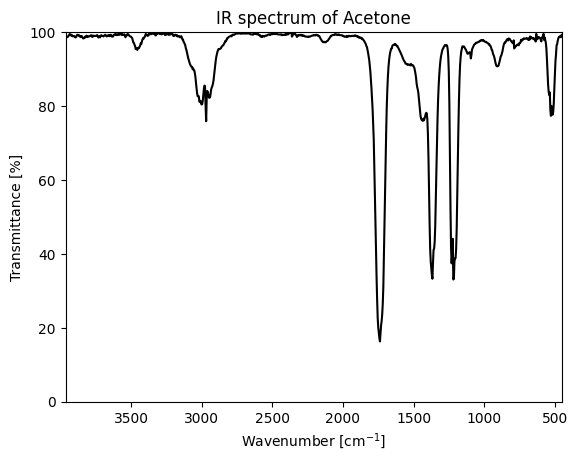

In [33]:
import nistchempy as nist
import sys
from pathlib import Path
import matplotlib.pyplot as plt

sys.path.append(str(Path.cwd().parent / "src" / "chemecho"))

from get_spectrum import extract_spectrum_data, ir_graph

compound = nist.get_compound("67-64-1")
data = extract_spectrum_data(compound)

fig, ax = ir_graph(data, compound.name)
plt.show()

For the skeletal formula, the function used is `draw_molecule`:

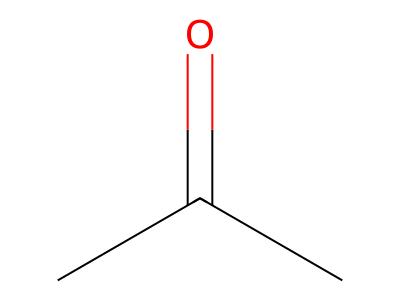

In [34]:
from utils import draw_molecule, molecule_3d_html, resolve_molecule

info = resolve_molecule("67-64-1")
smiles = info['smiles']
draw_molecule(smiles)

And for the 3D representation, the corresponding function is `molecule_3D_html`:

In [35]:
from IPython.display import HTML, display
display(HTML(molecule_3d_html(smiles)))

### Music generation



The main function that creates the MIDI files `molecular_music_fg`. However, there are also other functions that are crucial for a pleasing result. The first is `noise_reduction` that allows a smoothing of the noise present for high transmittances and that could cause additional frequency changes that are not relevant for the interpretztion of the spectrum. This function also excludes the first and last data points, which can sometimes cause trouble.

![IR spectrum noise](report_attachment/IR_spectrum_noise.png)

Then, the function `detect_functional_groups` allows for the detection of functional groups in the molecule. It uses the SMARTS, which is a language based on SMILES that specifies substructures in a molecule, of a functional group (included in dictionary at the beginning of the file) and transforms these into molecule objects, then checks if that molecule part is present in the compound of interest. Below is an example of the function working on acetone.

In [36]:
from musification_fg import detect_functional_groups

print (detect_functional_groups("CC(C)=O"))

['C-H (sp3)', 'C=O (carbonyl)']


The function `find_absorption_peaks` finds all peaks using a built in function from the `scipy` module, `find_peaks`, so they can be assigned to functional groups using the `assign_peaks_to_fgs` function. This last function links the functional groups detetected in the compound and the peaks found, by utilizing the wavenumber region assigned to different functional groups [8]. When there is an overlap of functional group peaks, it keeps only the most narrow region, as it is considered to be more specific. When a detected peak doesn't correspond to any functional group region listed, it doesn't keep it.

The function `_scale_accent_volume` is used to adapt the volume to a peak's intensity: if a peak is deeper, it will be louder.

Additional information on the number of carbons in the compound of interest is contained in the sequence of drum hits at the beginning of the music. This number of carbons is computed using the `count_carbons` function, which utilizes the SMILES of the molecule. An example of the function working on acetone is shown below.

In [37]:
from musification_fg import count_carbons

print (count_carbons("CC(C)=O"))

3


The function `molecular_weight_to_bpm` adapts the tempo of the music to the weight of the molecule, according to kinetic theory, as mentioned earlier. An example below shows that caffeine (a heavier molecule), will be slower than acetone (a lighter molecule).

In [38]:
from musification_fg import molecular_weight_to_bpm

caffeine=nist.get_compound('58-08-2')
acetone=nist.get_compound('67-64-1')

print (f"Caffeine is a heavier molecule, thus its sound is slower ({molecular_weight_to_bpm(caffeine)} bpm) than that of acetone ({molecular_weight_to_bpm(acetone)} bpm).")

Caffeine is a heavier molecule, thus its sound is slower (67 bpm) than that of acetone (85 bpm).


Lastly the `molecular_music_fg` function puts all these elements together and creates the compound's music.
It relies on the `musicpy` module to compose the music [9] and associates a prelude sequence indicating the number of carbon atoms in the molecule by a series of synth drum hits, and then reads the spectrum using the Fantasia sound pad for the peaks. It also includes times markers that correspond to wavenumber markers on a graphical IR spectrum: every 500 cm $^{-1}$ there is a kick drum beat, and every 100 cm $^{-1}$ there is a snare drum beat. It includes accent sounds by different instruments depending on the type of functional group detected in a given peak. The instruments for each peak are given in the table below. 

| Functional Group | Instrument (MIDI #) |
|------------------|---------------------|
| O-H (alcohol)    | Piccolo (73)        |
| O-H (carboxylic) | Clarinet (72)       |
| N-H              | Oboe (69)           |
| C-H (sp3)        | Nylon String Guitar (25) |
| C-H (aromatic)   | Steel String Guitar (26) |
| C#N (nitrile)    | Music Box (11)      |
| C#C (alkyne)     | Vibraphone (12)     |
| C=O (carbonyl)   | Orchestra Hit (56)  |
| C=C (alkene)     | Violin (41)         |
| aromatic ring    | Flute (74)          |
| C-O              | French Horn (61)    |
| N=O (nitro)      | Trumpet (57)        |


An example music for acetone is available below (in a separate webbrowser, as it was not achieved to include it in the notebook).


In [ ]:
from IPython.display import HTML, display
import base64
import tempfile
import os
import webbrowser
from musification_fg import molecular_music_fg

midi_path, legend = molecular_music_fg(data, compound, "CC(C)=O")

with open(midi_path, "rb") as f:
    midi_b64 = base64.b64encode(f.read()).decode()
os.remove(midi_path)

html_content = f"""
<html><body>
    <script src="https://cdn.jsdelivr.net/npm/tone@14/build/Tone.js"></script>
    <script src="https://cdn.jsdelivr.net/npm/@magenta/music@1.23.1/es6/core.js"></script>
    <script src="https://cdn.jsdelivr.net/npm/html-midi-player@1.5.0"></script>
    <midi-player
        src="data:audio/midi;base64,{midi_b64}"
        sound-font
        style="width:100%;">
    </midi-player>
</body></html>
"""

with tempfile.NamedTemporaryFile(mode='w', suffix='.html', delete=False) as f:
    f.write(html_content)
    tmp_path = f.name

webbrowser.open(f"file://{tmp_path}")

True

### Streamlit app

The purpose of the Streamlit app is to make the whole process easy and fluid, from data extraction to music generation. By a simple request, CAS, name, SMILES or empirical formula of the molecule, the skeletal formula, the 3D visualisation, the plotted and the musical IR spectrum are displayed, in the first or the second version as wanted. The user (sighted) also has the possibility to download documents of interest: IR spectrum plot and music in .svg and .mid format respectively. 

The app provides an integrated MIDI player, allowing to directly listen the results provided by the `molecular_music_fg` without using an external file player. 

![MIDI file player](report_attachment/MIDI_file_player.png)

Additionnaly, the list of functional groups detected in the spectrum is also available at the end of the page, completing the IR spectrum analysis. 

![functional groups table](report_attachment/functional_groups_table.png)

## Limitations and future implementations

Few features are for now not optimal, but this leaves room for improvement. Here are a list of actual limitations, that could be implemented in future versions:
- the catalogue of reference functional groups absorption is not complete. Some functions are missing, hence for some molecule, the app does not provide all the relevant information. Additionnaly, some peaks could be forgotten, considering overlapping of absorptions. 
- the carbons prelude could be modified for big molecules. Indeed, molecules with several tens of carbons have a quite long prelude in the actual version. One way of improvement could be to encode the number in a binary logic (ex: for 25 C, 0001 1001 could be expressed with only two different drums for 0 and 1) or to make separate sets of drums for each number (ex: for 25 C, a set of 2 drum and another of 5). 
- noise reduction could be enhanced by considering smoothing of IR transmittance curve, and to modify the choice of the threshold transmittance that is not optimal for some cases (for instance ethylene, whose maximal transmittance is only reached once and for which the noise is present at lower transmittance (see IR spectrum for more details)). 
- the actual version only displays the IR spectrum conversion into music, but other spectra could be added, like NMR or Mass spectra. 

## Conclusion 

The `chemecho` package constitutes a great tool for anyone who is interested in recent research about translation of molecular data into music as well as for visually impaired persons who do not have a broad access to chemical data displayed in graphical forms. This project provides an intuitive approach based on spectroscopic theory, while producing a pleasent sound that allows easy and straightforward comparisons between several spectra. Several functional groups are detected and signified by single notes thanks to reference values imported in code, use of SMARTS of fu,nctional groups and recognition of corresponding peaks. Finally, the Streamlit app provides an easy access to research tools displayed by the package and in just a few seconds 2D, 3D and audio representations of molecules. 

However, limitations exist, considering first errors on peaks detections. Indeed, some characteristic peaks of several functional groups may have the same domain of absorption, or some small peaks could be overlaped with bigger ones. Hence, it is crucial to have a critical mind on information displayed by the translation. Smoothing of transmittance could also be considered, in order to provide an even more enjoyable result, while keeping the relevant data from IR spectrum. 

## References

1. Dubus, G.; Bresin, R. A Systematic Review of Mapping Strategies for the Sonification of Physical Quantities. PLoS ONE 2013, 8 (12), e82491. https://doi.org/10.1371/journal.pone.0082491  

2. Kim, S. H.; Heller, E. J. Musical Molecules: Sonifying the IR Spectra and Modeling Intramolecular Vibrational Energy Redistribution of Small Molecules; arXiv 2026. https://doi.org/10.48550/arXiv.2601.02652  

3. Pereira, F.; Ponte-e-Sousa, J. C.; Fartaria, R. P. S.; Bonifácio, V. D. B.; Mata, P.; Aires-de-Sousa, J.; Lobo, A. M. Sonified Infrared Spectra and Their Interpretation by Blind and Visually Impaired Students. J. Chem. Educ. 2013, 90 (8), 1028–1031. https://doi.org/10.1021/ed4000124  

4. Zhou, C. J.; Zhou, E. R. Molecular Sonification: A Multi-Modal Approach for Enhanced AI in Drug Discovery. Med. Chem. Res. 2026, 35, 778–783. https://doi.org/10.1007/s00044-026-03549-y

5. Linstrom, P. J.; Mallard, W. G., Eds. NIST Chemistry WebBook, NIST Standard Reference Database Number 69; National Institute of Standards and Technology: Gaithersburg, MD, 1997. https://doi.org/10.18434/T4D303

6. National Institute of Standards and Technology. NIST Chemistry WebBook. https://webbook.nist.gov/chemistry/

7. Chernyshov, I. Y. NistChemPy: Unofficial Python Tools for Querying NIST Chemistry WebBook Pages, version 2.0.0; Zenodo, 2026. https://doi.org/10.5281/zenodo.20316418

8. Pavia, D. L.; Lampman, G. M.; Kriz, G. S.; Vyvyan, J. R. Introduction to Spectroscopy, 5th ed.; Cengage Learning: Boston, MA, 2015

9. musicpy Documentation; Read the Docs, 2026. https://musicpy.readthedocs.io/en/latest/